Title: Implement a program to build a Spam Filter using Natural Language Processing (NLP).




In [ ]:
import kagglehub
karthickveerakumar_spam_filter_path = kagglehub.dataset_download('karthickveerakumar/spam-filter')

print('Data source import complete.')

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



Using Colab cache for faster access to the 'spam-filter' dataset.
Data source import complete.
/kaggle/input/spam-filter/emails.csv


In [ ]:
"""Loading and Observing the Dataset"""

df = pd.read_csv(os.path.join(karthickveerakumar_spam_filter_path, 'emails.csv'))

df.head()

df.shape

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [ ]:
"""No Missing Values"""

df.isna().sum()



,0
text,0
spam,0


<Axes: ylabel='count'>

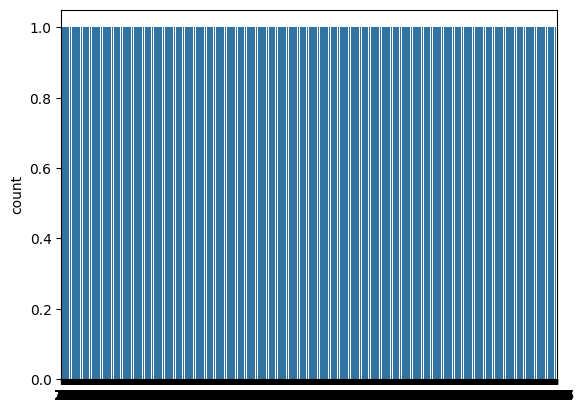

In [ ]:
"""Exploratory Data Analysis"""

df['spam'].value_counts()

sns.countplot(df['spam'])


In [ ]:
"""Checking the Length of email and it's relation"""

from nltk import word_tokenize



In [ ]:
"""Function that tokenizes each and every email into words and returns it's length"""

def count_words(text):
    words = word_tokenize(text)
    return len(words)

import nltk
nltk.download('punkt_tab')
df['count']=df['text'].apply(count_words)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
"""Applying the function to df['text'] and storing the count in another column"""

import nltk
nltk.download('punkt') # punkt is needed for word_tokenize

df['count']=df['text'].apply(count_words)

df['count']

df.groupby('spam')['count'].mean()



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


,count
spam,
0,346.835321
1,267.896199


In [ ]:
"""# Text Prepreocessing

**Function to Process the text data and 1. Remove Punctuation 2.Stop Words 3.Stemming**
"""

import string
from nltk.corpus import stopwords

def process_text(text):
    no_punc = [char for char in text if char not in string.punctuation]
    no_punc = ''.join(no_punc)

    return ' '.join([word for word in no_punc.split() if word.lower() not in stopwords.words('english')])

import nltk
nltk.download('stopwords')
df['text']=df['text'].apply(process_text)

df['text']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,text
0,Subject naturally irresistible corporate ident...
1,Subject stock trading gunslinger fanny merrill...
2,Subject unbelievable new homes made easy im wa...
3,Subject 4 color printing special request addit...
4,Subject money get software cds software compat...
...,...
5723,Subject research development charges gpg forwa...
5724,Subject receipts visit jim thanks invitation v...
5725,Subject enron case study update wow day super ...
5726,Subject interest david please call shirley cre...


In [ ]:
"""After cleaning the text. We will now carry out the process of Stemming to reduce infected words to their root"""

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def stemming (text):
    return ''.join([stemmer.stem(word) for word in text])

df['text']=df['text'].apply(stemming)

df.head()


,text,spam,count
0,subject naturally irresistible corporate ident...,1,325
1,subject stock trading gunslinger fanny merrill...,1,90
2,subject unbelievable new homes made easy im wa...,1,88
3,subject 4 color printing special request addit...,1,99
4,subject money get software cds software compat...,1,53


In [ ]:
"""**Now we will use Count Vectorizer to convert string data into Bag of Words ie Known Vocabulary**"""

from sklearn.feature_extraction.text import CountVectorizer
vectorizer= CountVectorizer()
message_bow = vectorizer.fit_transform(df['text'])

#print(vectorizer.get_feature_names())
#print(message_bow.toarray())


In [ ]:
"""**Splitting the Data[](http://)**"""

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(message_bow,df['spam'],test_size=0.20)


              precision    recall  f1-score   support

           0       1.00      0.99      1.00       880
           1       0.98      1.00      0.99       266

    accuracy                           0.99      1146
   macro avg       0.99      1.00      0.99      1146
weighted avg       0.99      0.99      0.99      1146

Accuracy using Cross Validation is : 99.07473879146757  %
The email is classified as: Spam


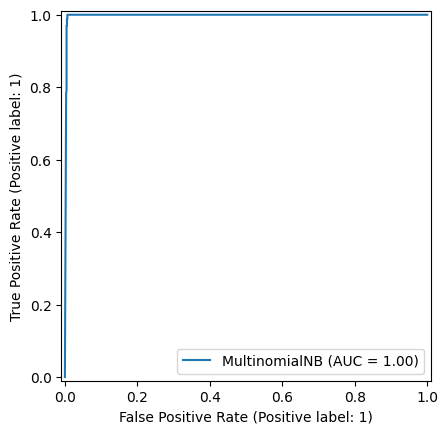

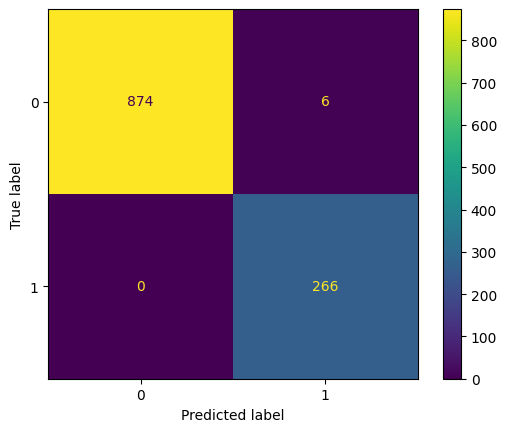

In [ ]:
"""# Creating the Model and it's Evaluation"""

from sklearn.naive_bayes import MultinomialNB
nb= MultinomialNB()
nb.fit(X_train,y_train)
y_pred = nb.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(nb, X_test, y_test)

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(nb,X_test,y_test)

from sklearn.model_selection import KFold, cross_val_score
kfold = KFold(n_splits=5,shuffle=True)
print("Accuracy using Cross Validation is :",np.mean(cross_val_score(nb,message_bow,df['spam'],cv=kfold,scoring="accuracy"))*100," %")

# Function to predict spam or not
def predict_spam(email_text):
    # Transform the input email text using the trained vectorizer
    email_features = vectorizer.transform([email_text])
    # Predict using the trained model
    prediction = nb.predict(email_features)
    # Return result as string
    if prediction[0] == 1:
        return "Spam"
    else:
        return "Not Spam"

# Example: test with your own email text
new_email = "Congratulations! You won a free lottery ticket. Call now!"
result = predict_spam(new_email)
print(f"The email is classified as: {result}")


In [ ]:
sms_data_path = kagglehub.dataset_download('uciml/sms-spam-collection-dataset')

# Construct the full path to the CSV file.
sms_csv_path = os.path.join(sms_data_path, 'spam.csv')

# Read the CSV file into a pandas DataFrame.
sms_df = pd.read_csv(sms_csv_path, encoding='latin-1')

# Display the first few rows and shape of the DataFrame.
display(sms_df.head())
display(sms_df.shape)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


(5572, 5)

In [ ]:
sms_df = sms_df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
sms_df = sms_df.rename(columns={'v1': 'label', 'v2': 'text'})
display(sms_df.head())

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
sms_df['text'] = sms_df['text'].apply(process_text)
sms_df['text'] = sms_df['text'].apply(stemming)
display(sms_df.head())

,label,text
0,ham,go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni
2,spam,free entry 2 wkly comp win fa cup final tkts 2...
3,ham,u dun say early hor u c already say
4,ham,nah dont think goes usf lives around though


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

sms_vectorizer = CountVectorizer()
sms_message_bow = sms_vectorizer.fit_transform(sms_df['text'])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train_sms, X_test_sms, y_train_sms, y_test_sms = train_test_split(sms_message_bow, sms_df['label'], test_size=0.2, random_state=42)

sms_nb_model = MultinomialNB()
sms_nb_model.fit(X_train_sms, y_train_sms)

MultinomialNB()

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       965
        spam       0.91      0.91      0.91       150

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115

Accuracy using Cross Validation is: 97.58 %


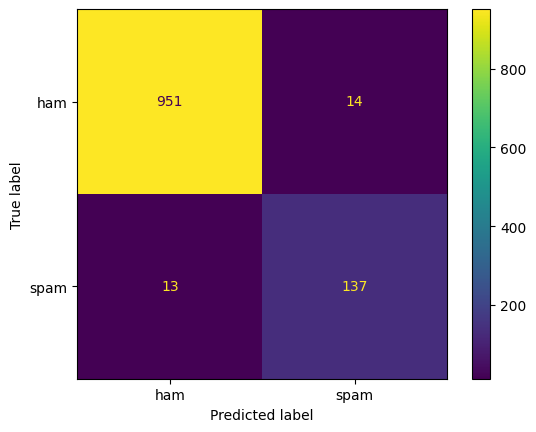

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import KFold, cross_val_score

# Use the trained SMS Naive Bayes model (sms_nb_model) to make predictions on the SMS test data (X_test_sms).
y_pred_sms = sms_nb_model.predict(X_test_sms)

# Print the classification report.
print(classification_report(y_test_sms, y_pred_sms))

# Create and display a confusion matrix.
ConfusionMatrixDisplay.from_estimator(sms_nb_model, X_test_sms, y_test_sms)

# Create a KFold object for cross-validation.
kfold = KFold(n_splits=5, shuffle=True)

# Calculate cross-validation accuracy.
cv_accuracy = cross_val_score(sms_nb_model, sms_message_bow, sms_df['label'], cv=kfold, scoring="accuracy")

# Print the mean cross-validation accuracy.
print(f"Accuracy using Cross Validation is: {np.mean(cv_accuracy)*100:.2f} %")

In [ ]:
def predict_sms_spam(sms_text):
    """Predicts if a given SMS message is spam or not.

    Args:
        sms_text: The text of the SMS message as a string.

    Returns:
        'spam' or 'ham' based on the model's prediction.
    """
    # Transform the input SMS text using the trained vectorizer
    sms_features = sms_vectorizer.transform([sms_text])
    # Predict using the trained model
    prediction = sms_nb_model.predict(sms_features)
    # Return result as string
    return prediction[0]

# Example usage
new_sms = "Congratulations! You've won a free prize. Claim now!"
result_sms = predict_sms_spam(new_sms)
print(f"The SMS is classified as: {result_sms}")

new_sms_ham = "Hey, let's meet up for coffee tomorrow."
result_sms_ham = predict_sms_spam(new_sms_ham)
print(f"The SMS is classified as: {result_sms_ham}")

The SMS is classified as: spam
The SMS is classified as: ham
